In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
raw_data=pd.read_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\zonar\1hoo.csv',sep=',',encoding='latin1') #Name the file as export
raw_datam=pd.read_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\zonar\1hoo_columns.csv',sep=',',encoding='latin1') #Name the file as export_columns
raw_datam.rename(columns={'Unnamed: 1':'Message Type',
                                 'Unnamed: 2':'Protocole',
                                 'Unnamed: 3':'IMEI',
                                 'Unnamed: 4':'Serial',
                                 'Unnamed: 5':'Mileage',
                                 'Unnamed: 6':'Date',
                                 'Unnamed: 7':'Ignition',
                                 'Unnamed: 8':'Latitude',
                                 'Unnamed: 9':'Longitude',
                                 'Unnamed: 10':'Altitude',
                                 'Unnamed: 11':'External Power',
                                 'Unnamed: 12':'RPM',
                                 'Unnamed: 13':'Speed',
                                 'Unnamed: 14':'Satellite Number',
                                 'Unnamed: 15':'Azimuth',
                                 'Unnamed: 16':'Battery level',
                                 },inplace=True)
raw_datam.info()
raw_datam.to_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\zonar\export_nammed.csv')

<class 'pandas.DataFrame'>
RangeIndex: 457 entries, 0 to 456
Columns: 125 entries, Message to Unnamed: 124
dtypes: str(125)
memory usage: 446.4 KB


In [3]:
unit=pd.read_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\zonar\export_nammed.csv',sep=',')
unit['Odometer in meters']=0.0
unit.info()
#unit_mileage=unit[unit['Date'].str.contains('2026-04-16T15')]
#unit_mileage[['Mileage','Date','IMEI']]

<class 'pandas.DataFrame'>
RangeIndex: 457 entries, 0 to 456
Columns: 127 entries, Unnamed: 0 to Odometer in meters
dtypes: float64(1), int64(1), str(125)
memory usage: 453.6 KB


Odometer

In [4]:
unit=pd.read_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\zonar\export_nammed.csv',sep=',')
unit_mileage=unit[unit['Date'].str.contains('2026')]
unit_mileage[['Mileage','Date','IMEI']]

,Mileage,Date,IMEI
2,Mileage:0,"Date:""2026-02-08T03:35:44Z""","Imei:""869487060224556"""
3,Mileage:0,"Date:""2026-02-08T03:35:46Z""","Imei:""869487060224556"""
4,Mileage:0,"Date:""2026-02-08T03:35:46Z""","Imei:""869487060224556"""
5,Mileage:0,"Date:""2026-02-08T03:35:47Z""","Imei:""869487060224556"""
8,Mileage:0,"Date:""2026-05-25T20:10:17Z""","Imei:""869487060224556"""
...,...,...,...
396,Mileage:148,"Date:""2026-05-27T18:20:34Z""","Imei:""869487060224556"""
397,Mileage:220,"Date:""2026-05-27T18:20:40Z""","Imei:""869487060224556"""
400,Mileage:243,"Date:""2026-05-27T18:22:57Z""","Imei:""869487060224556"""
402,Mileage:258,"Date:""2026-05-27T18:25:19Z""","Imei:""869487060224556"""


In [5]:
unit_odometer=unit[~unit['Protocole'].str.contains(':0')]
unit_odometer['Protocole'].value_counts()
#print("Unit odometer rows: ",unit_odometer.shape[0])

Protocole
ProtocolHeadType:20    38
ProtocolHeadType:19    30
Name: count, dtype: int64

Date:"2026-02-08T03:35:44Z"  ->  0 0.0
Date:"2026-02-08T03:35:46Z"  ->  1 0.0
Date:"2026-02-08T03:35:46Z"  ->  2 0.0
Date:"2026-02-08T03:35:47Z"  ->  3 0.0
Date:"2000-01-01T00:00:08Z"  ->  4 0.0
Date:"2000-01-01T00:00:08Z"  ->  5 0.0
Date:"2026-05-25T20:10:17Z"  ->  6 0.0
Date:"2026-05-25T20:10:39Z"  ->  7 0.0
Date:"2026-05-26T00:10:17Z"  ->  8 0.0
Date:"2026-05-26T16:15:12Z"  ->  9 0.0
Date:"2026-05-26T16:15:16Z"  ->  10 0.0
Date:"2026-05-26T16:15:18Z"  ->  11 842.0
Date:"2026-05-26T16:19:42Z"  ->  12 842.0
Date:"2026-05-26T16:21:17Z"  ->  13 842.0
Date:"2026-05-26T16:22:42Z"  ->  14 842.0
Date:"2026-05-26T16:26:18Z"  ->  15 842.0
Date:"2026-05-26T16:27:42Z"  ->  16 842.0
Date:"2026-05-26T16:28:22Z"  ->  17 842.0
Date:"2026-05-26T16:28:24Z"  ->  18 842.0
Date:"2026-05-26T16:28:25Z"  ->  19 842.0
Date:"2026-05-26T17:14:58Z"  ->  20 895.0
Date:"2026-05-26T17:15:59Z"  ->  21 895.0
Date:"2026-05-26T17:16:58Z"  ->  22 895.0
Date:"2026-05-26T17:17:55Z"  ->  23 895.0
Date:"2026-05-26T17:40:2

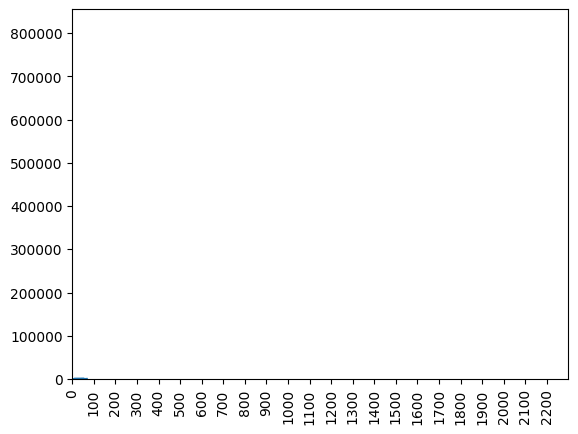

In [6]:
y_axis=[]
x_axis=[]
date=[]

for i in range(0,unit_odometer.shape[0]):
    #print(float(fsq694_m_odometer.iloc[i,6][8:15]))
    y_axis.append(float(unit_odometer.iloc[i,6][8:15]))
    x_axis.append(i)
    date.append(unit_odometer.iloc[i,7])

#print("Delta odometer: ",y_axis[170]-y_axis[133],'meters')

for i in range(0,unit_odometer.shape[0]):
    print(date[i],' -> ',x_axis[i],y_axis[i])

plt.ylim(0,855000)
plt.xlim(0,2300)
plt.yticks(range(0,855000,100000))
plt.xticks(range(0,2300,100),rotation=90)
plt.plot(x_axis,y_axis)

In/outs

PS I0 I1 I2 I3 I4 I5 DI0
15 14 13 12 11 10 09 08 07 06 05 04 03 02 01 00 
          1  0  0  0  0  0  0  0  0  0  0  0  0
          1  0  0  0  0  0  0  0  0  0  0  0  0
          1  0  0  0  0  0  0  0  0  0  0  0  0

In [7]:
#TopFly Pioneer.
aux_cad=[]
aux_date=[]
aux_raw_data=[]
aux_input_number=[]
raw_data_df=pd.DataFrame()
#cad='0x252513005900CE0869487064575128003C38402D000000644800000007000041000000FFFFFFFFFFFFFFFFFFFF00D500053670102604241257539A09BB44EE0997C2413ECB40000000F803312481FFFFFF0000190001FFFFFFx252514005908F40869487060215778003C38402D00000059500000000000002000000000000000FFFFFFFFFFFF42D50000AED51026042021294000E07E445A0D99C219C95D400000000003611173FFFFFF00001F0000FFFFFF'
#print(cad[106:118], cad[64:68], raw_data.shape[0])

for i in range(0,raw_data.shape[0]):
    long_cad=len(raw_data.iloc[i,2])
    if ((long_cad>48) & (long_cad<204)):
        aux_cad.append(raw_data.iloc[i,2])   

for i in range(0,len(aux_cad)):
    aux_value=aux_cad[i][64:68]
    aux_date.append(aux_cad[i][106:118])
    #aux_raw_data.append(aux_cad[i])       
    print(aux_cad[i][64:68],bin(int(aux_cad[i][64:68],16)),aux_cad[i][106:118],aux_cad[i])

print("len aux_cad: ",len(aux_cad))

3000 0b11000000000000 260208033544 0x252514005900010869487060224556003C38402D00000056CA0000050000003000000017271727FFFFFFFFFFFF1300000000001026020803354466661C42F9E2E342CD72B4410000005103491698FFFFFF00001B0002FFFFFF
0000 0b0 260208033546 0x252514005900020869487060224556003C38402D00000056CA0000050000000000000017291727FFFFFFFFFFFF4300000000001026020803354666661C42F9E2E342CD72B4410000005103501698FFFFFF00001B0002FFFFFF
0000 0b0 260208033546 0x252514005900030869487060224556003C38402D00000056CA0000050000000000000017291727FFFFFFFFFFFF4500000000001026020803354666661C42F9E2E342CD72B4410000005103501698FFFFFF00001B0002FFFFFF
8000 0b1000000000000000 260208033547 0x252514005900040869487060224556003C38402D00000056CA0000050000008000000017291727FFFFFFFFFFFF6800000000001026020803354766661C42F9E2E342CD72B4410000005103480310FFFFFF00001B0002FFFFFF
8000 0b1000000000000000 000101000008 0x252514005900050869487060224556003C38402D0000004BEA0000050000008000000000000000FFFFFFFFFFFF1200000000001000010100000866661

Satellites

In [8]:
date=[]
satellite_number=[]
for i in range(0,unit_odometer.shape[0]):   
    date.append(unit_odometer.iloc[i,7])
    satellite_number.append(int(unit_odometer.iloc[i,15][16:18]))

for i in range(0,unit_odometer.shape[0]):
    if satellite_number[i]<5:
        print(date[i],' -> ',satellite_number[i])

Date:"2026-05-27T12:59:38Z"  ->  0
Date:"2026-05-27T13:49:53Z"  ->  0
Date:"2026-05-27T13:50:02Z"  ->  0
Date:"2026-05-27T13:52:01Z"  ->  0
Date:"2026-05-27T17:12:04Z"  ->  0
Date:"2026-05-27T17:13:31Z"  ->  0
Date:"2026-05-27T17:15:11Z"  ->  0
Date:"2026-05-27T17:20:04Z"  ->  0
Date:"2026-05-27T17:20:53Z"  ->  0
Date:"2026-05-27T17:57:16Z"  ->  4


Power

In [9]:
date=[]
battery=[]
external_power=[]
inner_battery=[]
battery_df=unit_odometer[unit_odometer['Battery level'].str.contains('BatteryLevel')]

for i in range(0,battery_df.shape[0]):   
    date.append(battery_df.iloc[i,7])
    battery.append(int(battery_df.iloc[i,17][13:15]))
    external_power.append(float(battery_df.iloc[i,12][21:26]))

for i in range(0,battery_df.shape[0]):
    if external_power[i]<5:
        print(date[i],' -> ',external_power[i])

Date:"2026-05-26T16:15:18Z"  ->  0.9


In [10]:
int_bat_vol_1=raw_data[raw_data['Status'].str.contains('0x252514')]
int_bat_vol_2=raw_data[raw_data['Status'].str.contains('0x252513')]
int_bat_vol=pd.concat([int_bat_vol_1,int_bat_vol_2])
int_bat=[]
date_bat=[]
bat_df=pd.DataFrame()

for i in range(0,int_bat_vol.shape[0]):
    val=(float(int_bat_vol.iloc[i,2][150:154]))/100
    date_bat.append(int_bat_vol.iloc[i,2][106:119])
    int_bat.append(val)

for i in range(0,int_bat_vol.shape[0]):
    if int_bat[i]<3:
        bat_df['Date']=date_bat
        bat_df['int_bat']=int_bat

print(bat_df)

Empty DataFrame
Columns: []
Index: []


Pánico

In [11]:
aux_cad=[]
aux_date=[]
aux_raw_data=[]
#cad='0x252513005900CE0869487064575128003C38402D000000644800000007000041000000FFFFFFFFFFFFFFFFFFFF00D500053670102604241257539A09BB44EE0997C2413ECB40000000F803312481FFFFFF0000190001FFFFFFx252514005908F40869487060215778003C38402D00000059500000000000002000000000000000FFFFFFFFFFFF42D50000AED51026042021294000E07E445A0D99C219C95D400000000003611173FFFFFF00001F0000FFFFFF'
#print(cad[106:118], cad[64:68], raw_data.shape[0])

for i in range(0,raw_data.shape[0]):
    long_cad=len(raw_data.iloc[i,2])
    if ((long_cad>48) & (long_cad<204)):
        aux_cad.append(raw_data.iloc[i,2])   

for i in range(0,len(aux_cad)):
    aux_value=aux_cad[i][92:94]
    #print(aux_value)#, ' -> ',aux_date[i])
    aux_date.append(aux_cad[i][106:118])
    if aux_value=='03':
        print(aux_value, ' -> ',aux_date[i])

03  ->  260526161516
03  ->  260527171511


In [12]:
#TopFly HeroX
aux_cad=[]
aux_date=[]
aux_raw_data=[]
aux_input_number=[]
raw_data_df=pd.DataFrame()
#cad='0x252514005908F40869487060215778003C38402D00000059500000000000002000000000000000FFFFFFFFFFFF42D50000AED51026042021294000E07E445A0D99C219C95D400000000003611173FFFFFF00001F0000FFFFFF'
#print(cad[106:118])

for i in range(0,raw_data.shape[0]):
    long_cad=len(raw_data.iloc[i,2])
    if ((long_cad>48) & (long_cad<204)):
        aux_cad.append(raw_data.iloc[i,2])
    
for i in range(0,len(aux_cad)):    
    aux_value=aux_cad[i][64:68]
    if aux_value=='1000':
        aux_date.append(aux_cad[i][106:118])
        aux_raw_data.append(aux_cad[i])
        aux_input_number.append(2)
        print(aux_cad[i][64:68],bin(int(aux_cad[i][64:68],16)),aux_cad[i][106:118],aux_cad[i])

for i in range(0,len(aux_cad)):    
    aux_value=aux_cad[i][64:68]
    if aux_value=='2000':
        aux_date.append(aux_cad[i][106:118])
        aux_raw_data.append(aux_cad[i])
        aux_input_number.append(1)
        print(aux_cad[i][64:68],bin(int(aux_cad[i][64:68],16)),aux_cad[i][106:118],aux_cad[i])

raw_data_df['Date']=aux_date
raw_data_df['raw_data']=aux_raw_data
raw_data_df['Input']=aux_input_number

raw_data_df.to_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\zonar\17n3_to_jira.csv')

In [13]:
id=[]
one_wire=raw_data[raw_data['Message'].str.contains('OneWire')]

for i in range(0,one_wire.shape[0]):
    id.append(one_wire.iloc[i,2][84:100])

id

[]